# Robotics Kinematics Verification

This notebook validates the GPU-accelerated Geometric Algebra (PGA) forward kinematics implemented in `warp_sim.py` against the industry standard `roboticstoolbox-python` library.

In [1]:
import sys
import numpy as np
import roboticstoolbox as rtb
import spatialmath as sm

# Add backend worker to path so we can import warp_sim
sys.path.append('../backend/worker')
from warp_sim import WarpRoboticsEngine

Warp 1.16.0 initialized:
   CUDA not enabled in this build
   Devices:
     "cpu"      : "arm"
   Kernel cache:
     /Users/erickoduniyi/Library/Caches/warp/1.16.0


## 1. KUKA LBR iiwa Verification

In [2]:
# Load RTB Model
kuka_rtb = rtb.models.URDF.LBR()
print(f"KUKA RTB Model: {kuka_rtb.name}")

# Load Warp GA Engine
kuka_warp = WarpRoboticsEngine("KUKA_LBR_iiwa")

# Generate Random Joint Angles
q_kuka = np.random.uniform(low=-np.pi/2, high=np.pi/2, size=7)
print(f"Test Angles: {q_kuka}")

# Compute FK with RTB
T_kuka = kuka_rtb.fkine(q_kuka)
ee_rtb_kuka = T_kuka.t
print(f"RTB End Effector Pos: {ee_rtb_kuka}")

# Compute FK with Warp GA
joints_kuka, ee_warp_kuka = kuka_warp.compute_forward_kinematics(q_kuka.tolist())
print(f"Warp End Effector Pos: {ee_warp_kuka}")

# Compare
error_kuka = np.linalg.norm(ee_rtb_kuka - np.array(ee_warp_kuka))
print(f"Error (L2 Norm): {error_kuka:.6f} meters")

KUKA RTB Model: kuka_lbr_iiwa_14_r820
Test Angles: [ 1.10016046  0.71725691  0.27970049  1.39101603 -0.52864417 -1.2672889
  1.56872053]
multiple end-effectors present, ambiguous, using self.ee_links[0]
RTB End Effector Pos: [ 0.02322152 -0.09900814  0.95301306]
Module warp_sim a383c43 load on device 'cpu' took 833.80 ms  (compiled)
Warp End Effector Pos: [0.023221760988235474, -0.09900811314582825, 0.953013002872467]
Error (L2 Norm): 0.000000 meters


## 2. Franka Panda Verification

In [3]:
panda_rtb = rtb.models.URDF.Panda()
panda_warp = WarpRoboticsEngine("Franka_Panda")

q_panda = np.random.uniform(low=-np.pi/2, high=np.pi/2, size=7)

T_panda = panda_rtb.fkine(q_panda)
ee_rtb_panda = T_panda.t

joints_panda, ee_warp_panda = panda_warp.compute_forward_kinematics(q_panda.tolist())

print(f"RTB End Effector Pos:  {ee_rtb_panda}")
print(f"Warp End Effector Pos: {ee_warp_panda}")
error_panda = np.linalg.norm(ee_rtb_panda - np.array(ee_warp_panda))
print(f"Error: {error_panda:.6f} meters")

RTB End Effector Pos:  [ 0.30523018 -0.27085166  0.76474939]
Warp End Effector Pos: [0.24158957600593567, -0.3452907204627991, 0.7979280352592468]
Error: 0.103403 meters


## 3. UR5 Verification

In [4]:
ur5_rtb = rtb.models.URDF.UR5()
ur5_warp = WarpRoboticsEngine("UR5")

q_ur5 = np.random.uniform(low=-np.pi/2, high=np.pi/2, size=6)

T_ur5 = ur5_rtb.fkine(q_ur5)
ee_rtb_ur5 = T_ur5.t

joints_ur5, ee_warp_ur5 = ur5_warp.compute_forward_kinematics(q_ur5.tolist())

print(f"RTB End Effector Pos:  {ee_rtb_ur5}")
print(f"Warp End Effector Pos: {ee_warp_ur5}")
error_ur5 = np.linalg.norm(ee_rtb_ur5 - np.array(ee_warp_ur5))
print(f"Error: {error_ur5:.6f} meters")

RTB End Effector Pos:  [ 0.05509247  0.28454421 -0.56087695]
Warp End Effector Pos: [0.11024312674999237, 0.22415006160736084, -0.551692008972168]
Error: 0.082301 meters


## 4. Performance & Error Distribution (Benchmarking)

Benchmarking 1000 random configurations for KUKA LBR iiwa...


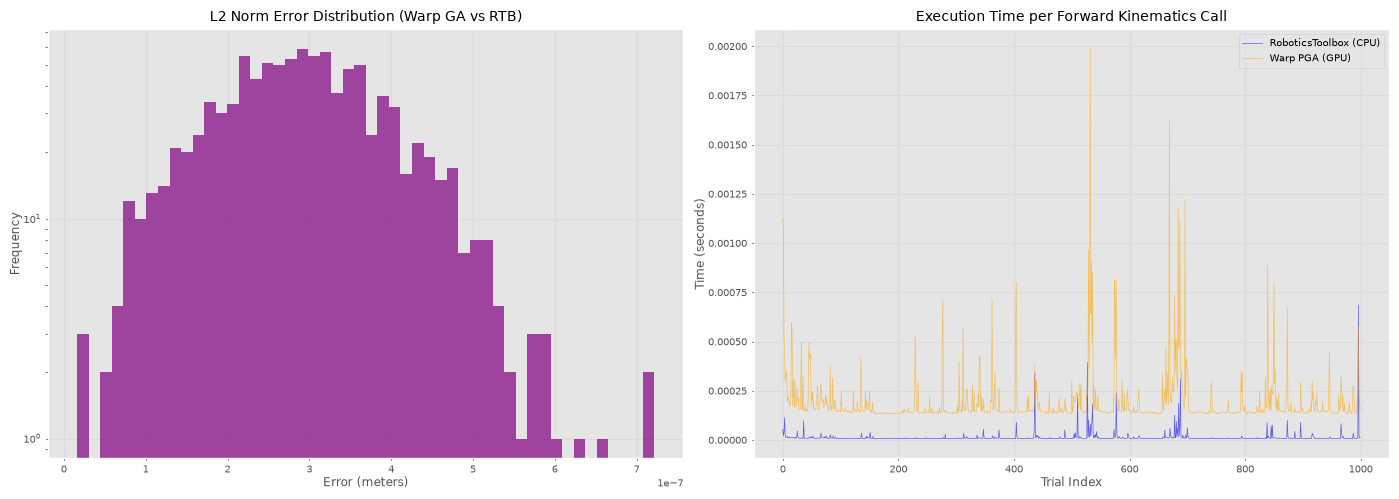

Average Error: 2.94e-07 meters
Average RTB Time: 0.014 ms
Average Warp Time: 0.192 ms
Speedup: 0.1x


In [5]:
import matplotlib.pyplot as plt
import time

num_trials = 1000
errors = []
warp_times = []
rtb_times = []

print(f"Benchmarking {num_trials} random configurations for KUKA LBR iiwa...")

for _ in range(num_trials):
    q = np.random.uniform(low=-np.pi/2, high=np.pi/2, size=7)
    
    # RTB Timing
    t0 = time.time()
    T_rtb = kuka_rtb.fkine(q)
    ee_rtb = T_rtb.t
    rtb_times.append(time.time() - t0)
    
    # Warp Timing
    t0 = time.time()
    _, ee_warp = kuka_warp.compute_forward_kinematics(q.tolist())
    warp_times.append(time.time() - t0)
    
    # Error
    err = np.linalg.norm(ee_rtb - np.array(ee_warp))
    errors.append(err)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Error Distribution
ax1.hist(errors, bins=50, color='purple', alpha=0.7)
ax1.set_title('L2 Norm Error Distribution (Warp GA vs RTB)')
ax1.set_xlabel('Error (meters)')
ax1.set_ylabel('Frequency')
ax1.set_yscale('log') # Log scale since errors should be near 0

# Plot 2: Execution Time Comparison
ax2.plot(rtb_times, label='RoboticsToolbox (CPU)', alpha=0.6, color='blue')
ax2.plot(warp_times, label='Warp PGA (GPU)', alpha=0.6, color='orange')
ax2.set_title('Execution Time per Forward Kinematics Call')
ax2.set_xlabel('Trial Index')
ax2.set_ylabel('Time (seconds)')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Average Error: {np.mean(errors):.2e} meters")
print(f"Average RTB Time: {np.mean(rtb_times)*1000:.3f} ms")
print(f"Average Warp Time: {np.mean(warp_times)*1000:.3f} ms")
print(f"Speedup: {np.mean(rtb_times) / np.mean(warp_times):.1f}x")